In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import GenerateEMRIWaveform, FastKerrEccentricEquatorialFlux

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI
from smt.sampling_methods import LHS


import os
import sys

# Changing directory to FEWNEW/work
# to import stuffs
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike_timemax  # TIME-MAXIMIZED VERSION
# import modeselectoralt
import parismc
# import gc
import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1/12     # Total time
print(f"Using dt = {dt} seconds, T = {T} years")

print('Initializing waveform generator...')
# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend # Force GPU
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,  # Force GPU
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
}

sum_kwargs_sep = {
    "force_backend": force_backend,  # Force GPU
    "pad_output": True,
    "separate_modes": True,
}

print("Creating GenerateEMRIWaveform class...")
# Kerr eccentric flux
waveform_gen_comb = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu
)

# Kerr eccentric flux
waveform_gen_sep = GenerateEMRIWaveform(
    FastKerrEccentricEquatorialFlux, 
    frame='detector',
    inspiral_kwargs=inspiral_kwargs, 
    amplitude_kwargs=amplitude_kwargs, 
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu
)


print('Done initializing waveform generator.')

print("Creating GravWaveAnalysis class...")
gwf = GWfuncs.GravWaveAnalysis(T, dt)

print("Initializing loglike class...")


# Source parameters
m1 = 1e6
m2 = 3e1
a = 0.7
p0 = 11.7 
e0 = 0.4
xI0 = 1.0
dist = 0.9  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5

params_star = (m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0)
param_true = [np.log10(m1), np.log10(m2), a, p0, e0]

# n-indexed mode selection parameters
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

# NOTE: change verbose argument for debugging
# Using n-indexed mode selection
loglike_obj = loglike_timemax.LogLikeTimeMax(
    params_star,
    waveform_gen_comb,
    gwf,
    verbose=False,
    waveform_gen_sep=waveform_gen_sep,
    ell=ell,
    n_vals=n_vals,
    M_mode=None  # No SNR filtering, use all n-groups
)

print('Done initializing loglike class.')
print('Calculating SNR...')
data = loglike_obj.signal
data_snr = gwf.rhostat(data)
print('SNR calculated:', data_snr)
print("Setting up log_density and prior functions...")


def log_density(params):
    params = np.asarray(params)

    n_samples = params.shape[0] 
    log_likes = np.zeros(n_samples)


    for i in range(n_samples):
        logm1, logm2, a, p0, e0 = params[i]
        m1 = 10**logm1
        m2 = 10**logm2

        loglike = loglike_obj(np.array([m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]))
        log_likes[i] = 10*loglike #NOTE: scaled 10x

    return log_likes

def prior_transform(u):
    logm1lim = [5.5, 6.5]     
    logm2lim = [1.0, 2.0]  
    alim = [0.01, 0.99]        
    p0lim = [8.0, 20.0] 
    e0lim = [0.1, 0.7]   

    transformed = np.zeros_like(u)

    # Uniform in log for masses

    # m1
    transformed[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]

    # m2
    transformed[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]

    # Linear in others 

    # a
    transformed[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]

    # p0
    transformed[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0] 

    # e0
    transformed[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]

    
    return transformed

    

print('Done setting up log-likelihood and prior.')

Using dt = 10 seconds, T = 0.08333333333333333 years
Initializing waveform generator...
Creating GenerateEMRIWaveform class...
Done initializing waveform generator.
Creating GravWaveAnalysis class...
Initializing loglike class...
Done initializing loglike class.
Calculating SNR...
SNR calculated: 5.97163342241979
Setting up log_density and prior functions...
Done setting up log-likelihood and prior.


In [2]:
sampler = parismc.Sampler.load_state('./search/intrinsic_ffunc_1mth_faceon_box1/sampler_state.pkl')

In [3]:
samples, weights = sampler.get_samples_with_weights(flatten=True)

/nfs/home/svu/e1498138/localgit/parismc/parismc/sampler.py:1332: RuntimeWarning: invalid value encountered in subtract
  weights = np.exp(self.searched_log_densities_list[j][:element_num] - self.loglike_normalization)


In [4]:
proc_pt = sampler.searched_points_list
proc_pt

[array([[0.980775  , 0.046525  , 0.075135  , 0.95618498, 0.039735  ],
        [0.98078135, 0.04652403, 0.07514736, 0.95619271, 0.03971334],
        [0.98077675, 0.04653217, 0.07514441, 0.95619338, 0.03973037],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],
       shape=(100000, 5)),
 array([[0.974895  , 0.20071501, 0.21625499, 0.99904501, 0.030555  ],
        [0.97488304, 0.20071331, 0.21625225, 0.99903343, 0.03055455],
        [0.97489797, 0.20070038, 0.21624646, 0.99904293, 0.03055196],
        ...,
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ]],
       shape=(100000, 5)),
 array([[0.96141499, 0.009695  , 0.086705  , 0.97321498, 0.082385  ],
        

In [5]:
logden_list = sampler.searched_log_densities_list
logden_list

[array([3.05534638e+16, 1.86749194e+16, 2.16677497e+16, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([2.15324631e+08, 2.89472671e+08, 2.13059025e+08, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([4.22401321e+79, 1.06464934e+83, 3.03827046e+81, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([5.40320226e+23, 1.93530386e+29, 5.66524284e+22, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([1.22841073e+27, 5.99657168e+26, 4.22861610e+28, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([9.86365292e+39, 5.45198436e+38, 1.96348161e+45, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([6.92486165e+10, 8.52448935e+10, 8.81792831e+10, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(100000,)),
 array([5.75706035e+20, 1.39777260e+22, 4.038848

In [6]:
# maxld_pt_1 = prior_transform(proc_pt[0][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt_1

In [7]:
# maxld_pt_2 = prior_transform(proc_pt[1][np.argmax(logden_list)].reshape(1, -1))
# maxld_pt_2

In [8]:
param_true

[np.float64(6.0), np.float64(1.4771212547196624), 0.7, 11.7, 0.4]

In [9]:
param_ranges = [(5.5,6.5),
                (1.0,2.0),
                (0.01,0.99),
                (8.0,20.0),
                (0.1,0.7)
                ]
param_ranges

[(5.5, 6.5), (1.0, 2.0), (0.01, 0.99), (8.0, 20.0), (0.1, 0.7)]

ValueError: Axis limits cannot be NaN or Inf

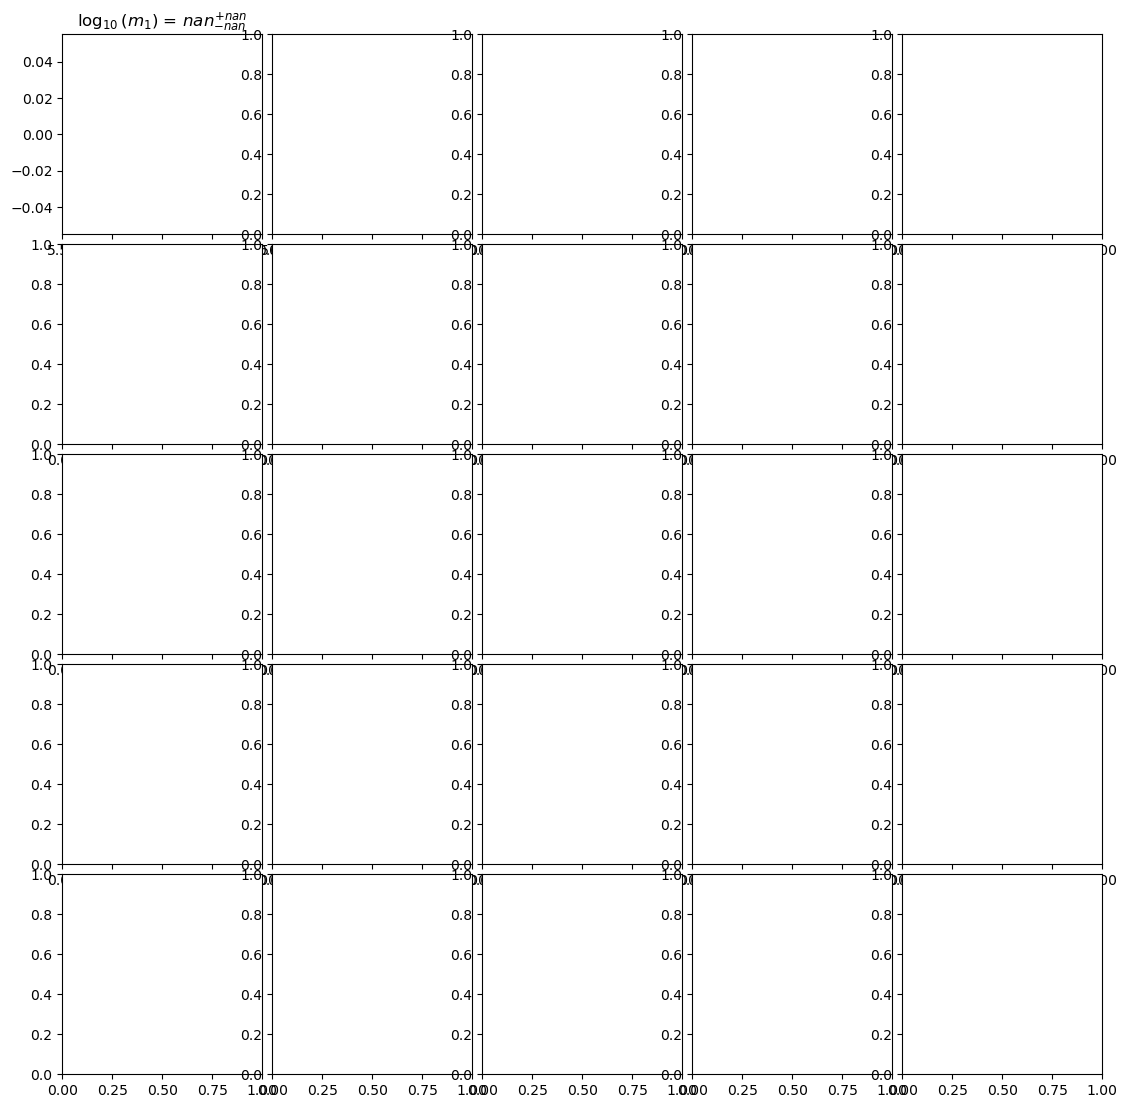

In [10]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

# corner.overplot_points(fig, maxld_pt_1.reshape(1, -1), 
#                        color='blue', marker='*', ms=10, 
#                        reverse=False)

# corner.overplot_points(fig, maxld_pt_2.reshape(1, -1), 
#                        color='orange', marker='*', ms=10,
#                        reverse=False)

